# CLIP-Based Post-Processing Filter — Wildfire Smoke & Fire Detection

**Pipeline:** YOLO11-S (DCT + AG×2) detects → crop bounding box → CLIP ViT-L/14 semantically verifies → keep or reject  
**Goal:** Reduce false positive rate from atmospheric confounders (haze, fog, overcast sky) without retraining  
**Primary target:** PyroNear val set (4,099 images, 754 hard negatives)  
**Hardware:** Kaggle 2×T4 (32GB total) → ViT-L/14 + batch=16  

---

### Evaluation Sets
| Set | Images | Hard Negatives | Notes |
|-----|--------|----------------|-------|
| Eval A — D-Fire test | 3,754 | 2,005 | Unified dataset test split |
| Eval B — Combined val | 7,025 | 2,129 | Unified dataset val split |
| Eval C — PyroNear val | 4,099 | 754 | Primary FP reduction target |

### Counting Methodology (image-level, matches ablation notebooks)
- **Hard negative + any kept detection** → **FP** 
- **Positive image + ≥1 kept detection** → **TP** 
- **Positive image + 0 kept detections** → **FN**

## 1. Setup & Installs

In [1]:
!pip install ultralytics open-clip-torch -q

import os, gc, csv, math, random, shutil, zipfile
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import open_clip
from PIL import Image
import cv2
from ultralytics import YOLO

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}     : {torch.cuda.get_device_name(i)}")
print(f"open_clip   : {open_clip.__version__}")
print("Libraries loaded ✅")

Torch       : 2.10.0+cu128
CUDA        : True
  GPU 0     : Tesla T4
  GPU 1     : Tesla T4
open_clip   : 3.3.0
Libraries loaded ✅


## 2. Configuration

In [2]:
!pip install datasets -q

import os, json, shutil
from pathlib import Path
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

# ── 1. D-Fire — Filter out close-up shots ─────────────────────────────────────
print("Processing D-Fire...")
DFIRE_PATH = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
dfire_kept = {}

def is_distant_shot(label_path, max_box_area=0.40):
    lbl = Path(label_path)
    if not lbl.exists(): return True
    with open(lbl) as f: lines = f.readlines()
    if not lines or all(l.strip() == '' for l in lines): return True
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5: continue
        _, xc, yc, bw, bh = map(float, parts)
        if bw * bh > max_box_area: return False
    return True

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    kept = []
    if img_dir.exists():
        for img_path in sorted(img_dir.glob("*.jpg")):
            lbl_path = lbl_dir / f"{img_path.stem}.txt"
            if is_distant_shot(lbl_path): kept.append(img_path)
    dfire_kept[split] = kept
print(f"  D-Fire kept: {sum(len(v) for v in dfire_kept.values())} images")


# ── 2. NEMO — Convert COCO JSON to YOLO ───────────────────────────────────────
print("\nProcessing NEMO...")
NEMO_BASE = "/kaggle/input/datasets/werus23/nevada-smoke-detection-data"
def coco_to_yolo(json_path, img_src_dir, img_dst_dir, lbl_dst_dir):
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(lbl_dst_dir, exist_ok=True)
    if not Path(json_path).exists(): return
    with open(json_path) as f: coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {}
    for ann in coco["annotations"]: ann_map.setdefault(ann["image_id"], []).append(ann)
    for img_id, img_info in img_map.items():
        W, H = img_info["width"], img_info["height"]
        fname = Path(img_info["file_name"]).stem
        src = Path(img_src_dir) / Path(img_info["file_name"]).name
        if src.exists(): shutil.copy2(src, Path(img_dst_dir) / src.name)
        lines = []
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann["bbox"]
            lines.append(f"0 {(x + w/2)/W:.6f} {(y + h/2)/H:.6f} {w/W:.6f} {h/H:.6f}")
        with open(Path(lbl_dst_dir) / f"{fname}.txt", "w") as f: f.write("\n".join(lines))

coco_to_yolo(f"{NEMO_BASE}/NEMO data/annotation_train.json", f"{NEMO_BASE}/NEMO data/train_images", "/kaggle/working/nemo_yolo/images/train", "/kaggle/working/nemo_yolo/labels/train")
coco_to_yolo(f"{NEMO_BASE}/NEMO data/annotation_val.json", f"{NEMO_BASE}/NEMO data/val_images", "/kaggle/working/nemo_yolo/images/val", "/kaggle/working/nemo_yolo/labels/val")
coco_to_yolo(f"{NEMO_BASE}/20-23_daytime_label.json", f"{NEMO_BASE}/20-23_daytime_images/daytime images", "/kaggle/working/nemo_yolo/images/train", "/kaggle/working/nemo_yolo/labels/train")
print("  NEMO conversion done.")


# ── 3. PyroNear — Download & Convert ──────────────────────────────────────────
print("\nProcessing PyroNear...")
try:
    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
except:
    print("Warning: HF_TOKEN secret not found. Attempting public access.")

ds = load_dataset("pyronear/pyro-sdis")
PYRO_DIRS = {"train_imgs": "/kaggle/working/pyro_yolo/images/train", "val_imgs": "/kaggle/working/pyro_yolo/images/val", 
             "train_lbls": "/kaggle/working/pyro_yolo/labels/train", "val_lbls": "/kaggle/working/pyro_yolo/labels/val"}
for d in PYRO_DIRS.values(): os.makedirs(d, exist_ok=True)

def save_pyro_split(split_data, img_dir, lbl_dir):
    for sample in split_data:
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = [f"0 {parts[1]} {parts[2]} {parts[3]} {parts[4]}" for parts in (line.strip().split() for line in ann.strip().split("\n")) if len(parts) == 5]
                f.write("\n".join(lines))

save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"])
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"])
print("  PyroNear download and conversion done.")


# ── 4. Merge into Unified Dataset ─────────────────────────────────────────────
print("\nMerging into Unified Dataset...")
UNIFIED = "/kaggle/working/unified_dataset"
for split in ["train", "val", "test"]:
    Path(f"{UNIFIED}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{UNIFIED}/labels/{split}").mkdir(parents=True, exist_ok=True)

    # Copy D-Fire
    for img_path in dfire_kept.get(split, []):
        shutil.copy2(img_path, f"{UNIFIED}/images/{split}/dfire_{img_path.name}")
        lbl = Path(f"{DFIRE_PATH}/{split}/labels") / f"{img_path.stem}.txt"
        if lbl.exists(): shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/dfire_{lbl.name}")

# Copy NEMO & PyroNear (Train/Val only)
for split in ["train", "val"]:
    for prefix, work_dir in [("nemo", "nemo_yolo"), ("pyro", "pyro_yolo")]:
        for img in Path(f"/kaggle/working/{work_dir}/images/{split}").glob("*.jpg"):
            shutil.copy2(img, f"{UNIFIED}/images/{split}/{prefix}_{img.name}")
        for lbl in Path(f"/kaggle/working/{work_dir}/labels/{split}").glob("*.txt"):
            shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/{prefix}_{lbl.name}")

print("Dataset loading and merging complete ✅")

Processing D-Fire...
  D-Fire kept: 18700 images

Processing NEMO...
  NEMO conversion done.

Processing PyroNear...
  PyroNear download and conversion done.

Merging into Unified Dataset...
Dataset loading and merging complete ✅


In [3]:
# ── MODEL PATH ───────────────────────────────────────────────────────────────
MODEL_PATH = "/kaggle/input/datasets/rayyansalha/dct-agskips/best.pt"  # ← drop in best.pt after ablation

# ── YOLO INFERENCE PARAMS ────────────────────────────────────────────────────
YOLO_CONF  = 0.25   # base confidence threshold (from threshold sweep notebook)
YOLO_IOU   = 0.50   # NMS IoU threshold

# ── DATASET PATHS ────────────────────────────────────────────────────────────
UNIFIED_BASE = "/kaggle/working/unified_dataset"   # merged D-Fire + NEMO + PyroNear
PYRO_BASE    = "/kaggle/working/pyro_yolo"          # PyroNear standalone

# Eval A — D-Fire test split (subset of unified, source prefix = dfire_)
EVAL_A_IMG_DIR = f"{UNIFIED_BASE}/images/test"
EVAL_A_LBL_DIR = f"{UNIFIED_BASE}/labels/test"

# Eval B — Combined val (full unified val)
EVAL_B_IMG_DIR = f"{UNIFIED_BASE}/images/val"
EVAL_B_LBL_DIR = f"{UNIFIED_BASE}/labels/val"

# Eval C — PyroNear val (primary target)
EVAL_C_IMG_DIR = f"{PYRO_BASE}/images/val"
EVAL_C_LBL_DIR = f"{PYRO_BASE}/labels/val"

# ── CLIP SETUP ───────────────────────────────────────────────────────────────
CLIP_MODEL_NAME = "ViT-L-14"
CLIP_PRETRAINED = "openai"
CLIP_BATCH_SIZE = 16    # 2×T4 = 32GB — ViT-L/14 safe at batch 16
CLIP_MIN_CROP   = 32    # skip CLIP for crops smaller than this (keep as-is)
CROP_PADDING    = 0.10  # 10% bbox padding for context

# ── CLIP FILTERING THRESHOLDS (defaults — swept below) ───────────────────────
SMOKE_CLIP_THRESH      = 0.20
FIRE_CLIP_THRESH       = 0.20
CONFOUNDER_CLIP_THRESH = 0.40

# ── OUTPUT PATHS ─────────────────────────────────────────────────────────────
OUT_DIR = Path("/kaggle/working")
OUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ["smoke", "fire"]
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Model path        : {MODEL_PATH}")
print(f"YOLO conf/iou     : {YOLO_CONF} / {YOLO_IOU}")
print(f"CLIP model        : {CLIP_MODEL_NAME} ({CLIP_PRETRAINED})")
print(f"CLIP batch size   : {CLIP_BATCH_SIZE}")
print(f"Smoke threshold   : {SMOKE_CLIP_THRESH}")
print(f"Fire threshold    : {FIRE_CLIP_THRESH}")
print(f"Confounder thresh : {CONFOUNDER_CLIP_THRESH}")
print(f"Device            : {DEVICE}")
print("Configuration set ✅")

Model path        : /kaggle/input/datasets/rayyansalha/dct-agskips/best.pt
YOLO conf/iou     : 0.25 / 0.5
CLIP model        : ViT-L-14 (openai)
CLIP batch size   : 16
Smoke threshold   : 0.2
Fire threshold    : 0.2
Confounder thresh : 0.4
Device            : cuda
Configuration set ✅


## 3. Custom Module Definitions

Define all custom attention modules used across ablation variants.  
Register all of them — safe to include unused ones so any `best.pt` drops in cleanly.

**Active in this model:** `MultiSpectralAttention`, `AttentionGate`  
**Stubs for other ablation variants:** `ChannelAttention`, `SpatialAttention`, `CBAM`

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── CBAM — Woo et al., ECCV 2018 ─────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """Shared MLP over avg-pooled and max-pooled channel descriptors."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        mid = max(1, channels // reduction)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))

class SpatialAttention(nn.Module):
    """7x7 depthwise conv over channel-pooled (avg+max) spatial map."""
    def __init__(self, kernel_size=7):
        super().__init__()
        assert kernel_size in (3, 7), "kernel_size must be 3 or 7"
        pad = kernel_size // 2
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=pad, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        pool = torch.cat(
            [x.mean(dim=1, keepdim=True), x.max(dim=1, keepdim=True).values], dim=1
        )
        return x * self.sigmoid(self.conv(pool))

class CBAM(nn.Module):
    """Full CBAM: channel attention -> spatial attention."""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.sa(self.ca(x))

# ── DCT + AG Modules (Actual Implementations) ─────────────────────────────────
class MultiSpectralAttention(nn.Module):
    """
    DCT-based channel attention — FcaNet (Qin et al., ICCV 2021).
    Fixed DCT filter bank + learned MLP.
    """
    def __init__(self, channels, dct_h=20, dct_w=20, reduction=16):
        super().__init__()
        self.channels = channels
        self.dct_h    = dct_h
        self.dct_w    = dct_w
        self.inp      = channels  

        dct_weight = self._build_dct_filter(channels, dct_h, dct_w)
        self.register_buffer('dct_weight', dct_weight)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    @staticmethod
    def _get_dct_components(num_channels, dct_h, dct_w):
        indices = sorted(
            [(u, v) for u in range(dct_h) for v in range(dct_w)],
            key=lambda x: x[0]**2 + x[1]**2
        )
        return indices[:num_channels]

    @staticmethod
    def _build_dct_filter(channels, dct_h, dct_w):
        components = MultiSpectralAttention._get_dct_components(channels, dct_h, dct_w)
        filters = torch.zeros(channels, dct_h, dct_w)
        for c, (u, v) in enumerate(components):
            for h in range(dct_h):
                for w in range(dct_w):
                    filters[c, h, w] = (
                        math.cos(math.pi * u * (2 * h + 1) / (2 * dct_h)) *
                        math.cos(math.pi * v * (2 * w + 1) / (2 * dct_w))
                    )
        norms = filters.reshape(channels, -1).norm(dim=1, keepdim=True).clamp(min=1e-8)
        filters = (filters.reshape(channels, -1) / norms).reshape(channels, dct_h, dct_w)
        return filters

    def forward(self, x):
        B, C, H, W = x.shape
        if H != self.dct_h or W != self.dct_w:
            x_dct = F.adaptive_avg_pool2d(x, (self.dct_h, self.dct_w))
        else:
            x_dct = x
        spectral = (x_dct * self.dct_weight.unsqueeze(0)).sum(dim=(-2, -1))
        attn = self.fc(spectral)
        return x * attn.view(B, C, 1, 1)


class AttentionGate(nn.Module):
    """
    Soft attention gate — Oktay et al., MICCAI 2018.
    Gates skip feature x using a coarser, semantically richer gating signal g.
    """
    def __init__(self, x_ch, g_ch, inter_ch=None):
        super().__init__()
        inter_ch     = inter_ch or max(x_ch // 2, 1)
        self.inp     = x_ch   
        self.W_x     = nn.Conv2d(x_ch,     inter_ch, kernel_size=1, bias=False)
        self.W_g     = nn.Conv2d(g_ch,     inter_ch, kernel_size=1, bias=False)
        self.psi     = nn.Conv2d(inter_ch, 1,        kernel_size=1, bias=False)
        self.bn      = nn.BatchNorm2d(inter_ch)
        self.relu    = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, inputs):
        x, g = inputs                           
        x1   = self.W_x(x)
        g1   = self.W_g(g)
        if g1.shape[2:] != x1.shape[2:]:       
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='nearest')
        attn = self.sigmoid(self.psi(self.relu(self.bn(x1 + g1))))
        return x * attn                         

print("Module definitions (CBAM + DCT + AG) OK ✅")

Module definitions (CBAM + DCT + AG) OK ✅


## 4. Register Custom Modules into Ultralytics Runtime

In [5]:
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod
import re as _re
import inspect as _inspect

_CUSTOM_CLASSES = {
    "CBAM":                  CBAM,
    "ChannelAttention":      ChannelAttention,
    "SpatialAttention":      SpatialAttention,
    "MultiSpectralAttention": MultiSpectralAttention,
    "AttentionGate":         AttentionGate,
}

# 1. Inject into all relevant Ultralytics namespaces
for mod in [conv_mod, ulm, tasks_mod]:
    for name, cls in _CUSTOM_CLASSES.items():
        setattr(mod, name, cls)
        mod.__dict__[name] = cls

# 2. Patch module_map dict
patched_map = False
for attr_name in ["module_map", "TASK_MAP", "__module_map__"]:
    obj = getattr(tasks_mod, attr_name, None)
    if isinstance(obj, dict) and len(obj) > 10:  
        for name, cls in _CUSTOM_CLASSES.items():
            obj[name] = cls
        print(f"Patched into tasks_mod.{attr_name} ✅")
        patched_map = True
        break

# 3. Scan all large dicts in tasks_mod as fallback
if not patched_map:
    for attr_name in dir(tasks_mod):
        obj = getattr(tasks_mod, attr_name, None)
        if isinstance(obj, dict) and "C2PSA" in str(obj):
            for name, cls in _CUSTOM_CLASSES.items():
                obj[name] = cls
            print(f"Patched into tasks_mod.{attr_name} (scan) ✅")
            patched_map = True
            break

if not patched_map:
    print("module_map not found — globals() fallback applied ✅")

print(f"Registered {len(_CUSTOM_CLASSES)} custom modules into Ultralytics runtime ✅")

# ── Patch parse_model for multi-from custom modules ──────────────────────────
_pm_src = _inspect.getsource(tasks_mod.parse_model)
_pm_patched = _re.sub(
    r'(\belse\b\s*:\s*\n\s*)(c2 = ch\[f\])',
    r'\1c2 = ch[f] if isinstance(f, int) else ch[f[0]]',
    _pm_src, count=1
)
if _pm_patched != _pm_src:
    _ns = {}
    exec(compile(_pm_patched, '<parse_model_patched>', 'exec'), {**tasks_mod.__dict__}, _ns)
    tasks_mod.parse_model = _ns['parse_model']
    print("parse_model patched: multi-from custom modules supported ✅")
else:
    print("WARNING: patch string not found — check Ultralytics version manually")

module_map not found — globals() fallback applied ✅
Registered 5 custom modules into Ultralytics runtime ✅
parse_model patched: multi-from custom modules supported ✅


## 5. Load YOLO Model

In [6]:
assert Path(MODEL_PATH).exists(), (
    f"Model not found: {MODEL_PATH}\n"
    "→ Set MODEL_PATH in Section 2 to your best.pt checkpoint"
)

yolo_model = YOLO(MODEL_PATH)
yolo_model.to(DEVICE)

# Warm-up pass
dummy = torch.zeros(1, 3, 640, 640).to(DEVICE)
_ = yolo_model.predict(source=dummy, verbose=False, conf=YOLO_CONF, iou=YOLO_IOU)
del dummy; gc.collect(); torch.cuda.empty_cache()

print(f"YOLO model loaded: {MODEL_PATH}")
print(f"Parameters       : {sum(p.numel() for p in yolo_model.model.parameters()):,}")
print("YOLO ready ✅")

YOLO model loaded: /kaggle/input/datasets/rayyansalha/dct-agskips/best.pt
Parameters       : 9,610,950
YOLO ready ✅


## 6. Load CLIP ViT-L/14 + Encode Text Prompts

In [7]:
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED
)
clip_model = clip_model.to(DEVICE).eval()
tokenizer  = open_clip.get_tokenizer(CLIP_MODEL_NAME)

# ── Text prompts — wildfire domain ────────────────────────────────────────────
TEXT_PROMPTS = [
    "smoke from a wildfire",            # idx 0 — target class 0
    "fire and flames from a wildfire",  # idx 1 — target class 1
    "atmospheric haze in the sky",      # idx 2 — confounder
    "fog or mist over landscape",       # idx 3 — confounder
    "clear sky with no smoke",          # idx 4 — confounder
    "dust or sand in the air",          # idx 5 — confounder
    "clouds in the sky",                # idx 6 — confounder
]

SMOKE_IDX       = 0
FIRE_IDX        = 1
CONFOUNDER_IDXS = [2, 3, 4, 5, 6]

# Pre-tokenize and encode text features once
text_tokens = tokenizer(TEXT_PROMPTS).to(DEVICE)
with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f"CLIP model        : {CLIP_MODEL_NAME} ({CLIP_PRETRAINED})")
print(f"Text feature shape: {text_features.shape}")
print(f"Text prompts      : {len(TEXT_PROMPTS)} ({len(CONFOUNDER_IDXS)} confounders)")
print("CLIP ready ✅")

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP model        : ViT-L-14 (openai)
Text feature shape: torch.Size([7, 768])
Text prompts      : 7 (5 confounders)
CLIP ready ✅


## 7. Core Filtering Functions

In [8]:
def pad_crop_bbox(img_w, img_h, x1, y1, x2, y2, pad=CROP_PADDING):
    """Apply proportional padding to bbox, clamped to image bounds."""
    bw, bh = x2 - x1, y2 - y1
    px, py  = bw * pad, bh * pad
    return (
        max(0,     int(x1 - px)),
        max(0,     int(y1 - py)),
        min(img_w, int(x2 + px)),
        min(img_h, int(y2 + py)),
    )


@torch.no_grad()
def clip_verify_batch(
    crops: list,          # list of PIL.Image
    classes: list,        # corresponding yolo class ints
    smoke_thresh:      float = SMOKE_CLIP_THRESH,
    fire_thresh:       float = FIRE_CLIP_THRESH,
    confounder_thresh: float = CONFOUNDER_CLIP_THRESH,
):
    """
    Batch CLIP verification.

    Returns:
        keeps   : list[bool]        — keep (True) or reject (False) per crop
        scores  : list[dict]        — per-prompt softmax probabilities per crop

    Logic per crop:
        - Encode with CLIP, compute softmax over all 7 prompts
        - Smoke (class 0): keep if smoke_prob > smoke_thresh
          AND max(confounder_probs) < confounder_thresh
        - Fire  (class 1): keep if fire_prob  > fire_thresh
          AND max(confounder_probs) < confounder_thresh
        - Crops < CLIP_MIN_CROP px: bypass CLIP, always keep
    """
    tensors = torch.stack([clip_preprocess(c) for c in crops]).to(DEVICE)
    img_features = clip_model.encode_image(tensors)
    img_features = img_features / img_features.norm(dim=-1, keepdim=True)
    similarities = (img_features @ text_features.T)       # (N, 7)
    probs        = similarities.softmax(dim=-1).cpu().numpy()  # (N, 7)

    keeps  = []
    scores = []
    for i, (cls, p) in enumerate(zip(classes, probs)):
        smoke_score      = p[SMOKE_IDX]
        fire_score       = p[FIRE_IDX]
        confounder_score = p[CONFOUNDER_IDXS].max()

        if cls == 0:
            keep = bool(smoke_score > smoke_thresh and confounder_score < confounder_thresh)
        else:
            keep = bool(fire_score  > fire_thresh  and confounder_score < confounder_thresh)

        keeps.append(keep)
        scores.append({prompt: float(p[i]) for i, prompt in enumerate(TEXT_PROMPTS)})

    return keeps, scores


def clip_verify_single(crop_pil, yolo_class, **kwargs):
    """Single-crop convenience wrapper."""
    keeps, scores = clip_verify_batch([crop_pil], [yolo_class], **kwargs)
    return keeps[0], scores[0]


print("Filtering functions defined ✅")

Filtering functions defined ✅


## 8. Inference Pipeline

In [9]:
def is_hard_negative(label_path):
    """Image is a hard negative if its label file is empty or missing."""
    p = Path(label_path)
    if not p.exists():
        return True
    content = p.read_text().strip()
    return content == ""


def run_pipeline(
    img_dir: str,
    lbl_dir: str,
    eval_name: str,
    smoke_thresh:      float = SMOKE_CLIP_THRESH,
    fire_thresh:       float = FIRE_CLIP_THRESH,
    confounder_thresh: float = CONFOUNDER_CLIP_THRESH,
    save_samples:      bool  = True,
    sample_dir:        str   = None,
):
    """
    Full YOLO → CLIP pipeline over an image directory.

    Image-level TP/FP/FN counting (matches ablation methodology):
      - Hard negative + any kept detection  → FP
      - Positive image + ≥1 kept detection  → TP
      - Positive image + 0 kept detections  → FN
      (Positive + 0 YOLO detections is also FN — CLIP cannot recover missed detections)

    Returns: dict with before/after metrics + per-image records for analysis
    """
    img_paths  = sorted(
        list(Path(img_dir).glob("*.jpg")) +
        list(Path(img_dir).glob("*.png"))
    )
    n_total    = len(img_paths)

    # ── Counters ─────────────────────────────────────────────────────────────
    before = {"TP": 0, "FP": 0, "FN": 0}
    after  = {"TP": 0, "FP": 0, "FN": 0}

    # Store sample detections for grid visualisation
    rejected_samples = []   # (img_path, box, clip_scores) — what CLIP filtered
    kept_samples     = []   # (img_path, box, clip_scores) — what CLIP passed

    print(f"\n{'─'*60}")
    print(f"Running: {eval_name}  ({n_total} images)")
    print(f"{'─'*60}")

    for idx, img_path in enumerate(img_paths):
        if (idx + 1) % 500 == 0 or idx == 0:
            pct = (idx + 1) / n_total * 100
            print(f"  [{idx+1:>5}/{n_total}] {pct:5.1f}%  "
                  f"before FP={before['FP']} TP={before['TP']} | "
                  f"after  FP={after['FP']} TP={after['TP']}")

        lbl_path   = Path(lbl_dir) / f"{img_path.stem}.txt"
        hard_neg   = is_hard_negative(lbl_path)

        # ── Run YOLO ─────────────────────────────────────────────────────────
        results = yolo_model.predict(
            source=str(img_path),
            conf=YOLO_CONF,
            iou=YOLO_IOU,
            verbose=False,
        )
        boxes = results[0].boxes  # may be empty

        n_yolo_dets = len(boxes) if boxes is not None else 0

        # ── Before-CLIP image-level counting ─────────────────────────────────
        if hard_neg:
            if n_yolo_dets > 0:
                before["FP"] += 1
        else:
            if n_yolo_dets > 0:
                before["TP"] += 1
            else:
                before["FN"] += 1

        # ── CLIP verify each detection ────────────────────────────────────────
        if n_yolo_dets == 0:
            # No detections: hard-neg → nothing to count; positive → FN
            if not hard_neg:
                after["FN"] += 1
            continue

        img_pil = Image.open(img_path).convert("RGB")
        W, H    = img_pil.size

        crops, crop_classes, crop_boxes = [], [], []
        tiny_keep = []  # indices of crops too small for CLIP → always keep

        for bi, box in enumerate(boxes.xyxy.cpu().numpy()):
            x1, y1, x2, y2 = box[:4]
            cls = int(boxes.cls[bi].item())
            px1, py1, px2, py2 = pad_crop_bbox(W, H, x1, y1, x2, y2)
            cw, ch = px2 - px1, py2 - py1
            if cw < CLIP_MIN_CROP or ch < CLIP_MIN_CROP:
                tiny_keep.append(bi)
                continue
            crop = img_pil.crop((px1, py1, px2, py2))
            crops.append(crop)
            crop_classes.append(cls)
            crop_boxes.append((bi, x1, y1, x2, y2, cls))

        # Batch CLIP over non-tiny crops
        clip_keeps   = []
        clip_scores_all = []
        for batch_start in range(0, len(crops), CLIP_BATCH_SIZE):
            b_crops   = crops[batch_start : batch_start + CLIP_BATCH_SIZE]
            b_classes = crop_classes[batch_start : batch_start + CLIP_BATCH_SIZE]
            b_keeps, b_scores = clip_verify_batch(
                b_crops, b_classes,
                smoke_thresh=smoke_thresh,
                fire_thresh=fire_thresh,
                confounder_thresh=confounder_thresh,
            )
            clip_keeps.extend(b_keeps)
            clip_scores_all.extend(b_scores)

        # Combine: tiny crops always kept, others from CLIP
        any_kept = len(tiny_keep) > 0  # tiny crops always survive
        for keep_flag, (bi, x1, y1, x2, y2, cls), crop, sc in zip(
            clip_keeps, crop_boxes, crops, clip_scores_all
        ):
            if keep_flag:
                any_kept = True
                if save_samples and len(kept_samples) < 50:
                    kept_samples.append((img_path, (x1, y1, x2, y2), cls, sc))
            else:
                if save_samples and len(rejected_samples) < 50:
                    rejected_samples.append((img_path, (x1, y1, x2, y2), cls, sc))

        # ── After-CLIP image-level counting ──────────────────────────────────
        if hard_neg:
            if any_kept:
                after["FP"] += 1
        else:
            if any_kept:
                after["TP"] += 1
            else:
                after["FN"] += 1

    # ── Compute metrics ───────────────────────────────────────────────────────
    def metrics(counts):
        tp, fp, fn = counts["TP"], counts["FP"], counts["FN"]
        recall  = tp / max(tp + fn, 1) * 100
        fp_rate = fp / max(tp + fp + fn, 1) * 100  # FP / (TP+FP+FN) image-level
        return {"TP": tp, "FP": fp, "FN": fn, "Recall": recall, "FP_Rate": fp_rate}

    result = {
        "eval_name":       eval_name,
        "n_images":        n_total,
        "before":          metrics(before),
        "after":           metrics(after),
        "rejected_samples": rejected_samples,
        "kept_samples":     kept_samples,
    }

    # ── Summary print ─────────────────────────────────────────────────────────
    print(f"\n  ── {eval_name} Results ────────────────────────────")
    print(f"  {'':25s} {'TP':>6} {'FP':>6} {'FN':>6}  {'Recall':>8}  {'FP Rate':>8}")
    print(f"  {'Before CLIP':25s} {before['TP']:>6} {before['FP']:>6} {before['FN']:>6}  "
          f"{result['before']['Recall']:>7.1f}%  {result['before']['FP_Rate']:>7.1f}%")
    print(f"  {'After  CLIP':25s} {after['TP']:>6} {after['FP']:>6} {after['FN']:>6}  "
          f"{result['after']['Recall']:>7.1f}%  {result['after']['FP_Rate']:>7.1f}%")
    d_recall  = result['after']['Recall']  - result['before']['Recall']
    d_fp_rate = result['after']['FP_Rate'] - result['before']['FP_Rate']
    print(f"  {'Delta':25s} {'':>6} {'':>6} {'':>6}  "
          f"{d_recall:>+7.1f}%  {d_fp_rate:>+7.1f}%")
    print(f"  {'─'*60}")

    return result


print("Pipeline function defined ✅")

Pipeline function defined ✅


## 9. Eval A — D-Fire Test Set

In [10]:
results_a = run_pipeline(
    img_dir   = EVAL_A_IMG_DIR,
    lbl_dir   = EVAL_A_LBL_DIR,
    eval_name = "Eval A — D-Fire Test",
)


────────────────────────────────────────────────────────────
Running: Eval A — D-Fire Test  (3754 images)
────────────────────────────────────────────────────────────
  [    1/3754]   0.0%  before FP=0 TP=0 | after  FP=0 TP=0
  [  500/3754]  13.3%  before FP=10 TP=1 | after  FP=1 TP=0
  [ 1000/3754]  26.6%  before FP=19 TP=7 | after  FP=4 TP=0
  [ 1500/3754]  40.0%  before FP=19 TP=479 | after  FP=4 TP=62
  [ 2000/3754]  53.3%  before FP=22 TP=791 | after  FP=4 TP=109
  [ 2500/3754]  66.6%  before FP=23 TP=792 | after  FP=4 TP=109
  [ 3000/3754]  79.9%  before FP=32 TP=910 | after  FP=6 TP=149
  [ 3500/3754]  93.2%  before FP=32 TP=1368 | after  FP=6 TP=272

  ── Eval A — D-Fire Test Results ────────────────────────────
                                TP     FP     FN    Recall   FP Rate
  Before CLIP                 1585     32    164     90.6%      1.8%
  After  CLIP                  303      6   1446     17.3%      0.3%
  Delta                                             -73.3%    

## 10. Eval B — Combined Val Set

In [11]:
results_b = run_pipeline(
    img_dir   = EVAL_B_IMG_DIR,
    lbl_dir   = EVAL_B_LBL_DIR,
    eval_name = "Eval B — Combined Val",
)


────────────────────────────────────────────────────────────
Running: Eval B — Combined Val  (7025 images)
────────────────────────────────────────────────────────────
  [    1/7025]   0.0%  before FP=0 TP=0 | after  FP=0 TP=0
  [  500/7025]   7.1%  before FP=8 TP=0 | after  FP=2 TP=0
  [ 1000/7025]  14.2%  before FP=17 TP=273 | after  FP=2 TP=30
  [ 1500/7025]  21.4%  before FP=18 TP=571 | after  FP=2 TP=71
  [ 2000/7025]  28.5%  before FP=23 TP=578 | after  FP=3 TP=72
  [ 2500/7025]  35.6%  before FP=23 TP=1037 | after  FP=3 TP=175
  [ 3000/7025]  42.7%  before FP=54 TP=1412 | after  FP=20 TP=238
  [ 3500/7025]  49.8%  before FP=183 TP=1722 | after  FP=90 TP=403
  [ 4000/7025]  56.9%  before FP=280 TP=2025 | after  FP=126 TP=504
  [ 4500/7025]  64.1%  before FP=308 TP=2448 | after  FP=151 TP=852
  [ 5000/7025]  71.2%  before FP=352 TP=2885 | after  FP=186 TP=1180
  [ 5500/7025]  78.3%  before FP=360 TP=3330 | after  FP=193 TP=1481
  [ 6000/7025]  85.4%  before FP=392 TP=3686 | after

## 11. Eval C — PyroNear Val Set (Primary Target)

In [12]:
results_c = run_pipeline(
    img_dir   = EVAL_C_IMG_DIR,
    lbl_dir   = EVAL_C_LBL_DIR,
    eval_name = "Eval C — PyroNear Val",
    save_samples = True,
)


────────────────────────────────────────────────────────────
Running: Eval C — PyroNear Val  (4099 images)
────────────────────────────────────────────────────────────
  [    1/4099]   0.0%  before FP=0 TP=0 | after  FP=0 TP=0
  [  500/4099]  12.2%  before FP=140 TP=298 | after  FP=83 TP=177
  [ 1000/4099]  24.4%  before FP=240 TP=609 | after  FP=120 TP=282
  [ 1500/4099]  36.6%  before FP=285 TP=994 | after  FP=148 TP=580
  [ 2000/4099]  48.8%  before FP=329 TP=1433 | after  FP=183 TP=897
  [ 2500/4099]  61.0%  before FP=337 TP=1890 | after  FP=190 TP=1221
  [ 3000/4099]  73.2%  before FP=369 TP=2233 | after  FP=194 TP=1321
  [ 3500/4099]  85.4%  before FP=381 TP=2679 | after  FP=204 TP=1441
  [ 4000/4099]  97.6%  before FP=441 TP=3031 | after  FP=223 TP=1662

  ── Eval C — PyroNear Val Results ────────────────────────────
                                TP     FP     FN    Recall   FP Rate
  Before CLIP                 3079    441    266     92.0%     11.6%
  After  CLIP            

## 12. Save Results Table (Before vs After, All Eval Sets)

In [13]:
rows = []
for res in [results_a, results_b, results_c]:
    for phase in ["before", "after"]:
        m = res[phase]
        rows.append({
            "eval_set":  res["eval_name"],
            "phase":     phase,
            "n_images":  res["n_images"],
            "TP":        m["TP"],
            "FP":        m["FP"],
            "FN":        m["FN"],
            "Recall_%":  round(m["Recall"],  2),
            "FP_Rate_%": round(m["FP_Rate"], 2),
        })

df_results = pd.DataFrame(rows)
df_results.to_csv(OUT_DIR / "clip_filter_results.csv", index=False)
print(df_results.to_string(index=False))
print("\nSaved → clip_filter_results.csv ✅")

             eval_set  phase  n_images   TP  FP   FN  Recall_%  FP_Rate_%
 Eval A — D-Fire Test before      3754 1585  32  164     90.62       1.80
 Eval A — D-Fire Test  after      3754  303   6 1446     17.32       0.34
Eval B — Combined Val before      7025 4459 464  437     91.07       8.66
Eval B — Combined Val  after      7025 1881 226 3015     38.42       4.41
Eval C — PyroNear Val before      4099 3079 441  266     92.05      11.65
Eval C — PyroNear Val  after      4099 1665 223 1680     49.78       6.25

Saved → clip_filter_results.csv ✅


## 13. CLIP Threshold Sweep — Smoke Threshold

Sweep `SMOKE_CLIP_THRESH` from 0.10 → 0.50 (step 0.05)  
`CONFOUNDER_CLIP_THRESH` held fixed at 0.40

In [14]:
def sweep_threshold(
    img_dir:    str,
    lbl_dir:    str,
    sweep_param: str,           # "smoke" or "confounder"
    sweep_vals:  list,
    fixed_smoke:      float,
    fixed_fire:       float,
    fixed_confounder: float,
):
    """
    Run the pipeline over one eval set for each threshold value.
    Returns list of dicts: {thresh, recall, fp_rate}
    """
    img_paths = sorted(
        list(Path(img_dir).glob("*.jpg")) +
        list(Path(img_dir).glob("*.png"))
    )

    # Pre-run YOLO on all images once — expensive to re-run for each thresh
    print(f"Pre-running YOLO on {len(img_paths)} images for sweep...")
    per_image_data = []  # list of (hard_neg, crops, crop_classes)

    for img_path in img_paths:
        lbl_path = Path(lbl_dir) / f"{img_path.stem}.txt"
        hard_neg = is_hard_negative(lbl_path)

        results   = yolo_model.predict(
            source=str(img_path), conf=YOLO_CONF, iou=YOLO_IOU, verbose=False
        )
        boxes     = results[0].boxes
        n_dets    = len(boxes) if boxes is not None else 0

        crops, crop_classes, tiny_count = [], [], 0
        if n_dets > 0:
            img_pil = Image.open(img_path).convert("RGB")
            W, H    = img_pil.size
            for bi, box in enumerate(boxes.xyxy.cpu().numpy()):
                x1, y1, x2, y2 = box[:4]
                cls = int(boxes.cls[bi].item())
                px1, py1, px2, py2 = pad_crop_bbox(W, H, x1, y1, x2, y2)
                cw, ch = px2 - px1, py2 - py1
                if cw < CLIP_MIN_CROP or ch < CLIP_MIN_CROP:
                    tiny_count += 1
                    continue
                crops.append(img_pil.crop((px1, py1, px2, py2)))
                crop_classes.append(cls)

        per_image_data.append({
            "hard_neg":    hard_neg,
            "n_yolo_dets": n_dets,
            "crops":       crops,
            "classes":     crop_classes,
            "tiny_kept":   tiny_count,
        })

    # Pre-compute CLIP features for ALL crops (model output agnostic of thresh)
    print("Pre-computing CLIP image features for all crops...")
    all_probs = []  # per image: np array (n_crops, 7) or None
    for data in per_image_data:
        if not data["crops"]:
            all_probs.append(None)
            continue
        batch_probs = []
        for bs in range(0, len(data["crops"]), CLIP_BATCH_SIZE):
            b_crops   = data["crops"][bs : bs + CLIP_BATCH_SIZE]
            b_classes = data["classes"][bs : bs + CLIP_BATCH_SIZE]
            tensors   = torch.stack([clip_preprocess(c) for c in b_crops]).to(DEVICE)
            with torch.no_grad():
                feats = clip_model.encode_image(tensors)
                feats = feats / feats.norm(dim=-1, keepdim=True)
                sims  = (feats @ text_features.T)
                probs = sims.softmax(dim=-1).cpu().numpy()
            batch_probs.append(probs)
        all_probs.append(np.concatenate(batch_probs, axis=0))

    print(f"CLIP pre-computation done. Sweeping {sweep_param} threshold...")

    # Now sweep thresholds cheaply (just threshold the cached probs)
    sweep_results = []
    for val in sweep_vals:
        s_thresh = val          if sweep_param == "smoke"      else fixed_smoke
        f_thresh = val          if sweep_param == "smoke"      else fixed_fire
        c_thresh = fixed_confounder if sweep_param == "smoke" else val

        tp = fp = fn = 0
        for data, probs in zip(per_image_data, all_probs):
            hard_neg    = data["hard_neg"]
            n_yolo_dets = data["n_yolo_dets"]
            tiny_kept   = data["tiny_kept"]

            if n_yolo_dets == 0:
                if not hard_neg:
                    fn += 1
                continue
            
            any_kept = tiny_kept > 0
            if probs is not None:
                for i, cls in enumerate(data["classes"]):
                    p = probs[i]
                    smoke_score = p[SMOKE_IDX]
                    fire_score  = p[FIRE_IDX]
                    conf_score  = p[CONFOUNDER_IDXS].max()
                    if cls == 0:
                        keep = smoke_score > s_thresh and conf_score < c_thresh
                    else:
                        keep = fire_score  > f_thresh and conf_score < c_thresh
                    if keep:
                        any_kept = True

            if hard_neg:
                if any_kept:
                    fp += 1
            else:
                if any_kept:
                    tp += 1
                else:
                    fn += 1

        recall  = tp / max(tp + fn, 1) * 100
        fp_rate = fp / max(tp + fp + fn, 1) * 100
        sweep_results.append({"thresh": val, "recall": recall, "fp_rate": fp_rate})
        print(f"  {sweep_param}={val:.2f}  →  Recall {recall:5.1f}%  FP Rate {fp_rate:5.1f}%")

    return sweep_results


print("Sweep function defined ✅")

Sweep function defined ✅


In [15]:
# Sweep smoke threshold — PyroNear val (primary target)
SMOKE_SWEEP_VALS = [round(v, 2) for v in np.arange(0.10, 0.51, 0.05)]

smoke_sweep = sweep_threshold(
    img_dir          = EVAL_C_IMG_DIR,
    lbl_dir          = EVAL_C_LBL_DIR,
    sweep_param      = "smoke",
    sweep_vals       = SMOKE_SWEEP_VALS,
    fixed_smoke      = SMOKE_CLIP_THRESH,
    fixed_fire       = FIRE_CLIP_THRESH,
    fixed_confounder = CONFOUNDER_CLIP_THRESH,
)

df_smoke_sweep = pd.DataFrame(smoke_sweep)
df_smoke_sweep.to_csv(OUT_DIR / "clip_smoke_thresh_sweep.csv", index=False)
print("\nSmoke threshold sweep complete ✅")

Pre-running YOLO on 4099 images for sweep...
Pre-computing CLIP image features for all crops...
CLIP pre-computation done. Sweeping smoke threshold...
  smoke=0.10  →  Recall  92.0%  FP Rate  11.6%
  smoke=0.15  →  Recall  49.8%  FP Rate   6.2%
  smoke=0.20  →  Recall  49.8%  FP Rate   6.2%
  smoke=0.25  →  Recall  49.8%  FP Rate   6.2%
  smoke=0.30  →  Recall  49.8%  FP Rate   6.2%
  smoke=0.35  →  Recall  49.8%  FP Rate   6.2%
  smoke=0.40  →  Recall  49.8%  FP Rate   6.2%
  smoke=0.45  →  Recall  49.8%  FP Rate   6.2%
  smoke=0.50  →  Recall  49.8%  FP Rate   6.2%

Smoke threshold sweep complete ✅


## 14. Identify Optimal Smoke Threshold

In [16]:
# Find optimal: maximise FP reduction while keeping recall drop ≤ 5%
baseline_recall = results_c["before"]["Recall"]
RECALL_BUDGET   = 5.0   # max acceptable recall drop in percentage points

feasible = [
    r for r in smoke_sweep
    if baseline_recall - r["recall"] <= RECALL_BUDGET
]
optimal_smoke_row = min(feasible, key=lambda r: r["fp_rate"]) if feasible else smoke_sweep[-1]
OPTIMAL_SMOKE_THRESH = optimal_smoke_row["thresh"]

print(f"Baseline recall         : {baseline_recall:.1f}%")
print(f"Recall budget (max drop): {RECALL_BUDGET:.1f} pp")
print(f"Optimal smoke threshold : {OPTIMAL_SMOKE_THRESH}")
print(f"  → Recall {optimal_smoke_row['recall']:.1f}%  FP Rate {optimal_smoke_row['fp_rate']:.1f}%")

Baseline recall         : 92.0%
Recall budget (max drop): 5.0 pp
Optimal smoke threshold : 0.1
  → Recall 92.0%  FP Rate 11.6%


## 15. CLIP Threshold Sweep — Confounder Threshold

Sweep `CONFOUNDER_CLIP_THRESH` from 0.25 → 0.60 (step 0.05)  
`SMOKE_CLIP_THRESH` fixed at optimal from previous sweep

In [17]:
CONFOUNDER_SWEEP_VALS = [round(v, 2) for v in np.arange(0.25, 0.61, 0.05)]

confounder_sweep = sweep_threshold(
    img_dir          = EVAL_C_IMG_DIR,
    lbl_dir          = EVAL_C_LBL_DIR,
    sweep_param      = "confounder",
    sweep_vals       = CONFOUNDER_SWEEP_VALS,
    fixed_smoke      = OPTIMAL_SMOKE_THRESH,
    fixed_fire       = OPTIMAL_SMOKE_THRESH,   # mirror fire thresh
    fixed_confounder = CONFOUNDER_CLIP_THRESH,
)

df_conf_sweep = pd.DataFrame(confounder_sweep)
df_conf_sweep.to_csv(OUT_DIR / "clip_confounder_thresh_sweep.csv", index=False)

# Find optimal confounder threshold
feasible_c = [
    r for r in confounder_sweep
    if baseline_recall - r["recall"] <= RECALL_BUDGET
]
optimal_conf_row = min(feasible_c, key=lambda r: r["fp_rate"]) if feasible_c else confounder_sweep[0]
OPTIMAL_CONF_THRESH = optimal_conf_row["thresh"]

print(f"\nOptimal confounder threshold: {OPTIMAL_CONF_THRESH}")
print(f"  → Recall {optimal_conf_row['recall']:.1f}%  FP Rate {optimal_conf_row['fp_rate']:.1f}%")
print("Confounder threshold sweep complete ✅")

Pre-running YOLO on 4099 images for sweep...
Pre-computing CLIP image features for all crops...
CLIP pre-computation done. Sweeping confounder threshold...
  confounder=0.25  →  Recall  92.0%  FP Rate  11.6%
  confounder=0.30  →  Recall  92.0%  FP Rate  11.6%
  confounder=0.35  →  Recall  92.0%  FP Rate  11.6%
  confounder=0.40  →  Recall  92.0%  FP Rate  11.6%
  confounder=0.45  →  Recall  92.0%  FP Rate  11.6%
  confounder=0.50  →  Recall  92.0%  FP Rate  11.6%
  confounder=0.55  →  Recall  92.0%  FP Rate  11.6%
  confounder=0.60  →  Recall  92.0%  FP Rate  11.6%

Optimal confounder threshold: 0.25
  → Recall 92.0%  FP Rate 11.6%
Confounder threshold sweep complete ✅


## 16. Visualisations

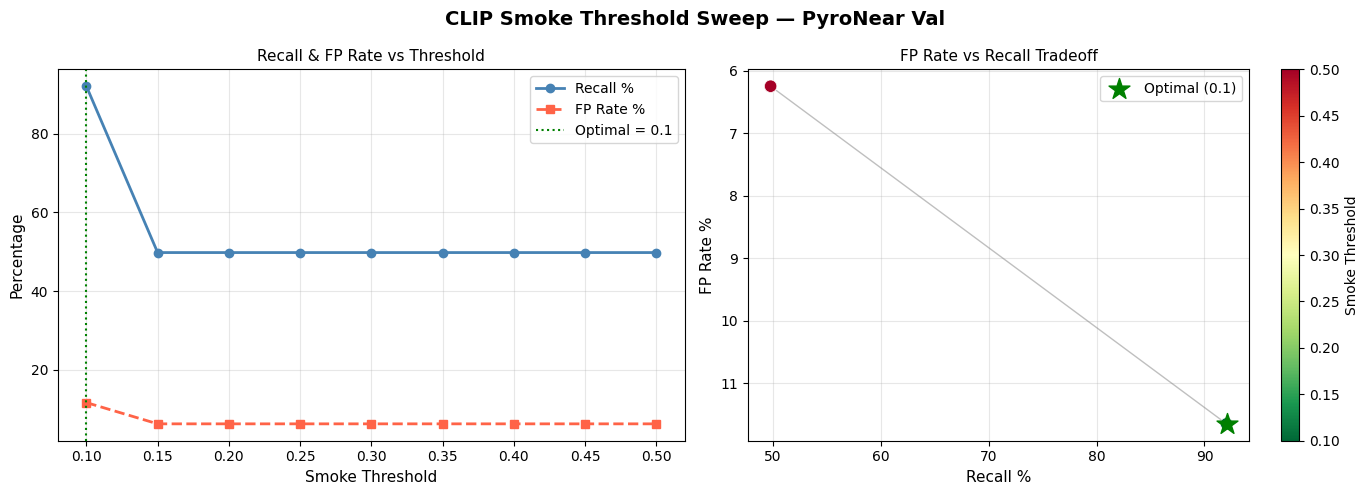

Saved → clip_smoke_thresh_sweep.png


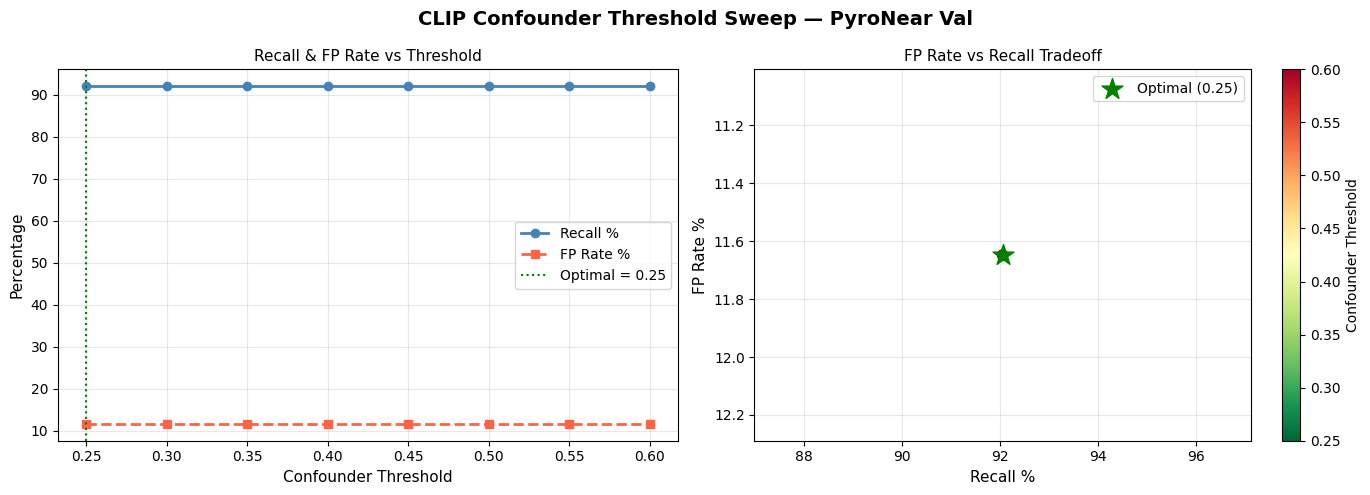

Saved → clip_confounder_thresh_sweep.png


In [18]:
# ── Helper: threshold sweep plot ──────────────────────────────────────────────
def plot_threshold_sweep(sweep_data, sweep_param, optimal_thresh, save_path):
    threshs  = [r["thresh"]  for r in sweep_data]
    recalls  = [r["recall"]  for r in sweep_data]
    fp_rates = [r["fp_rate"] for r in sweep_data]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"CLIP {sweep_param.capitalize()} Threshold Sweep — PyroNear Val",
        fontsize=14, fontweight="bold"
    )

    # Left: Recall and FP Rate vs threshold
    ax = axes[0]
    ax.plot(threshs, recalls,  "o-", color="steelblue", label="Recall %", linewidth=2)
    ax.plot(threshs, fp_rates, "s--", color="tomato",   label="FP Rate %", linewidth=2)
    ax.axvline(optimal_thresh, color="green", linestyle=":", linewidth=1.5,
               label=f"Optimal = {optimal_thresh}")
    ax.set_xlabel(f"{sweep_param.capitalize()} Threshold", fontsize=11)
    ax.set_ylabel("Percentage", fontsize=11)
    ax.set_title("Recall & FP Rate vs Threshold", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Right: FP Rate vs Recall tradeoff curve
    ax2 = axes[1]
    scatter = ax2.scatter(recalls, fp_rates, c=threshs, cmap="RdYlGn_r",
                          s=80, zorder=3, edgecolors="white", linewidth=0.5)
    ax2.plot(recalls, fp_rates, "-", color="gray", alpha=0.5, linewidth=1)
    plt.colorbar(scatter, ax=ax2, label=f"{sweep_param.capitalize()} Threshold")

    # Annotate optimal
    opt_idx = threshs.index(optimal_thresh)
    ax2.scatter([recalls[opt_idx]], [fp_rates[opt_idx]],
                marker="*", s=250, color="green", zorder=5,
                label=f"Optimal ({optimal_thresh})")
    ax2.set_xlabel("Recall %", fontsize=11)
    ax2.set_ylabel("FP Rate %", fontsize=11)
    ax2.set_title("FP Rate vs Recall Tradeoff", fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.invert_yaxis()  # lower FP rate = better = top

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {Path(save_path).name}")


plot_threshold_sweep(
    smoke_sweep, "smoke", OPTIMAL_SMOKE_THRESH,
    OUT_DIR / "clip_smoke_thresh_sweep.png"
)

plot_threshold_sweep(
    confounder_sweep, "confounder", OPTIMAL_CONF_THRESH,
    OUT_DIR / "clip_confounder_thresh_sweep.png"
)

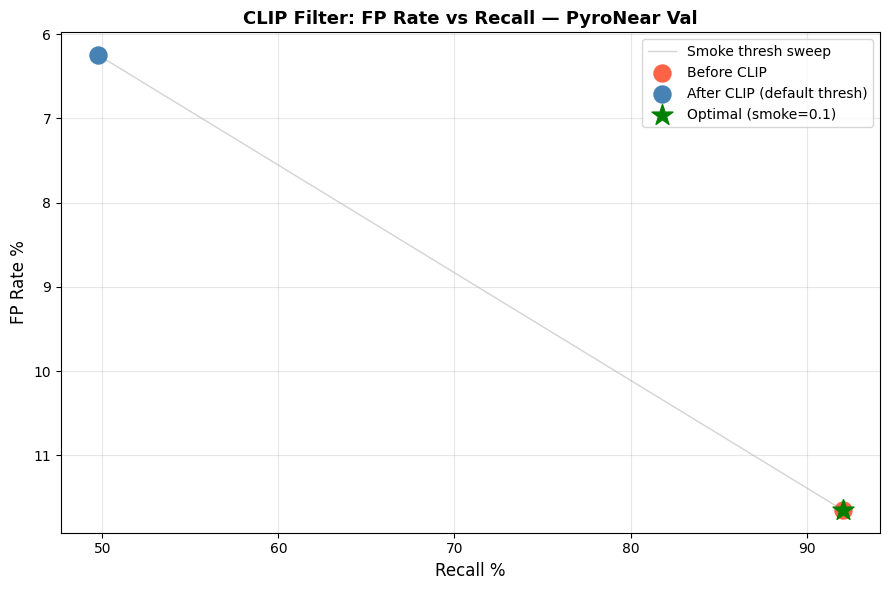

Saved → clip_fp_recall_pyronear.png ✅


In [19]:
# ── Before vs After FP Rate / Recall — PyroNear ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("CLIP Filter: FP Rate vs Recall — PyroNear Val",
             fontsize=13, fontweight="bold")

# Background tradeoff curve from smoke sweep
recalls_sw  = [r["recall"]  for r in smoke_sweep]
fp_rates_sw = [r["fp_rate"] for r in smoke_sweep]
ax.plot(recalls_sw, fp_rates_sw, "-", color="lightgray", linewidth=1,
        label="Smoke thresh sweep", zorder=1)

# Before
ax.scatter(
    [results_c["before"]["Recall"]],
    [results_c["before"]["FP_Rate"]],
    s=150, marker="o", color="tomato", zorder=5, label="Before CLIP"
)
# After (default thresholds)
ax.scatter(
    [results_c["after"]["Recall"]],
    [results_c["after"]["FP_Rate"]],
    s=150, marker="o", color="steelblue", zorder=5, label="After CLIP (default thresh)"
)
# Optimal operating point
ax.scatter(
    [optimal_smoke_row["recall"]],
    [optimal_smoke_row["fp_rate"]],
    s=250, marker="*", color="green", zorder=6,
    label=f"Optimal (smoke={OPTIMAL_SMOKE_THRESH})"
)

ax.set_xlabel("Recall %", fontsize=12)
ax.set_ylabel("FP Rate %", fontsize=12)
ax.invert_yaxis()
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "clip_fp_recall_pyronear.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → clip_fp_recall_pyronear.png ✅")

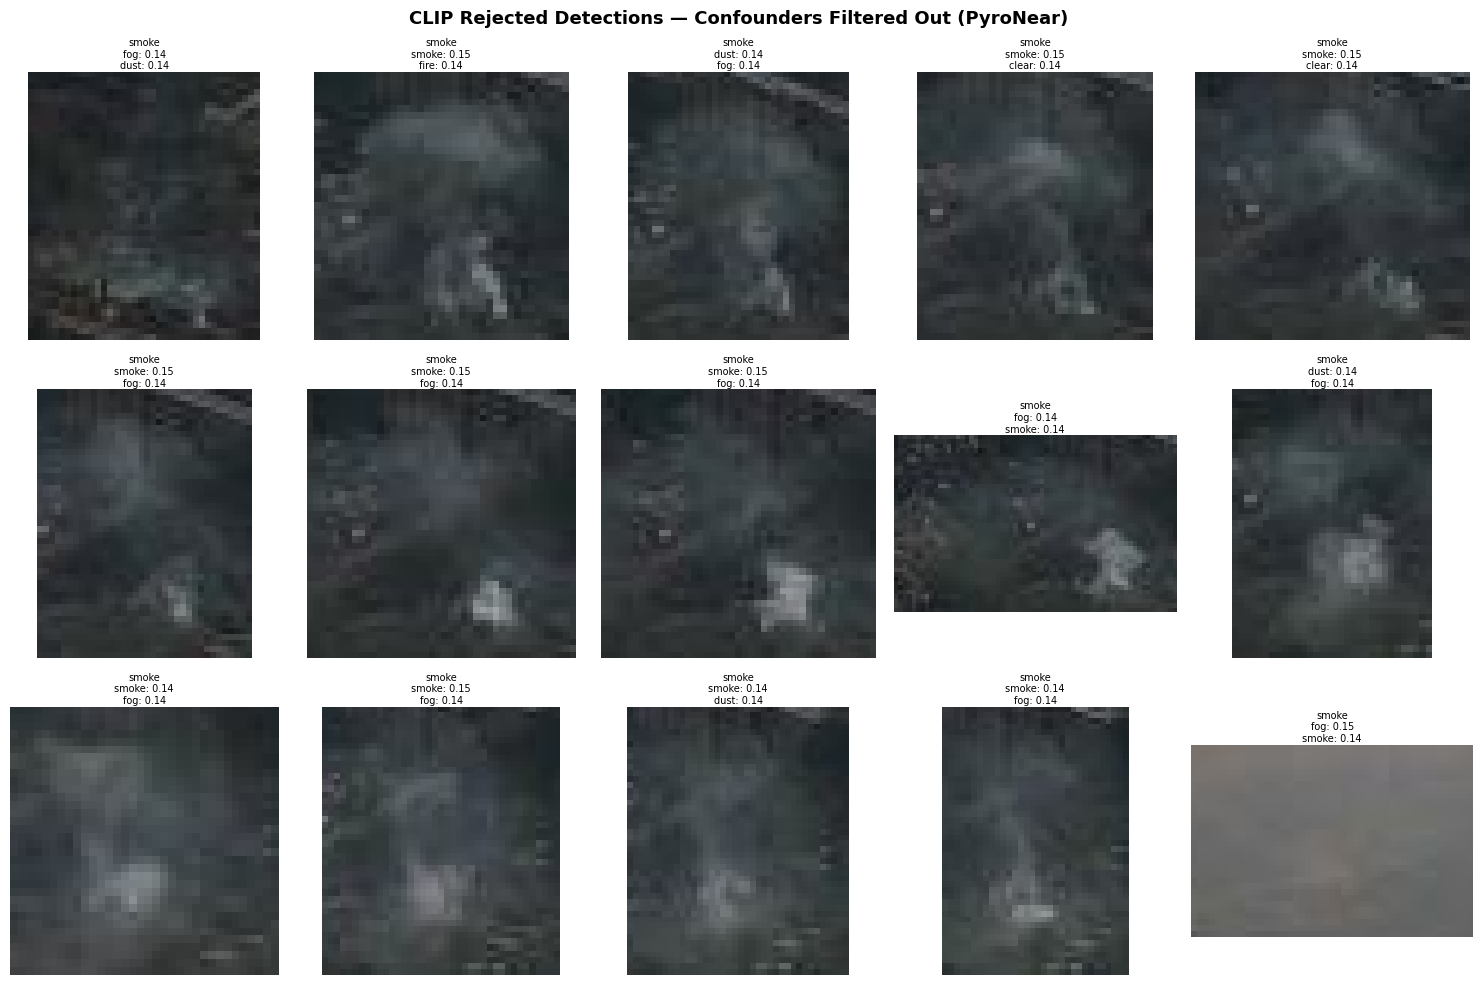

Saved → clip_rejected_samples.png
No samples to plot for: CLIP Kept Detections — Genuine Smoke/Fire (PyroNear)


In [20]:
# ── Sample grids: rejected vs kept detections ─────────────────────────────────
def plot_sample_grid(samples, title, save_path, n_cols=5, n_rows=3):
    """Grid of cropped detections with CLIP top scores."""
    n = min(len(samples), n_cols * n_rows)
    if n == 0:
        print(f"No samples to plot for: {title}")
        return

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3 + 1))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    axes = axes.flatten()

    for i, (img_path, box, cls, sc) in enumerate(samples[:n]):
        ax = axes[i]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size
        x1, y1, x2, y2 = box
        px1, py1, px2, py2 = pad_crop_bbox(W, H, x1, y1, x2, y2)
        crop = img.crop((px1, py1, px2, py2))
        ax.imshow(crop)

        # Top 2 CLIP scores
        sorted_sc  = sorted(sc.items(), key=lambda kv: kv[1], reverse=True)[:2]
        label_text = (
            f"{CLASS_NAMES[cls]}\n"
            + "\n".join(f"{k.split()[0]}: {v:.2f}" for k, v in sorted_sc)
        )
        ax.set_title(label_text, fontsize=7, pad=2)
        ax.axis("off")

    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {Path(save_path).name}")


plot_sample_grid(
    results_c["rejected_samples"],
    "CLIP Rejected Detections — Confounders Filtered Out (PyroNear)",
    OUT_DIR / "clip_rejected_samples.png",
)

plot_sample_grid(
    results_c["kept_samples"],
    "CLIP Kept Detections — Genuine Smoke/Fire (PyroNear)",
    OUT_DIR / "clip_kept_samples.png",
)

## 17. Optimal Threshold Recommendation

In [21]:
# Re-run Eval C with optimal thresholds for the final recommendation
results_c_optimal = run_pipeline(
    img_dir          = EVAL_C_IMG_DIR,
    lbl_dir          = EVAL_C_LBL_DIR,
    eval_name        = "Eval C — PyroNear Val (OPTIMAL THRESHOLDS)",
    smoke_thresh     = OPTIMAL_SMOKE_THRESH,
    fire_thresh      = OPTIMAL_SMOKE_THRESH,
    confounder_thresh= OPTIMAL_CONF_THRESH,
    save_samples     = False,
)


────────────────────────────────────────────────────────────
Running: Eval C — PyroNear Val (OPTIMAL THRESHOLDS)  (4099 images)
────────────────────────────────────────────────────────────
  [    1/4099]   0.0%  before FP=0 TP=0 | after  FP=0 TP=0
  [  500/4099]  12.2%  before FP=140 TP=298 | after  FP=140 TP=298
  [ 1000/4099]  24.4%  before FP=240 TP=609 | after  FP=240 TP=609
  [ 1500/4099]  36.6%  before FP=285 TP=994 | after  FP=285 TP=994
  [ 2000/4099]  48.8%  before FP=329 TP=1433 | after  FP=329 TP=1433
  [ 2500/4099]  61.0%  before FP=337 TP=1890 | after  FP=337 TP=1890
  [ 3000/4099]  73.2%  before FP=369 TP=2233 | after  FP=369 TP=2233
  [ 3500/4099]  85.4%  before FP=381 TP=2679 | after  FP=381 TP=2679
  [ 4000/4099]  97.6%  before FP=441 TP=3031 | after  FP=441 TP=3031

  ── Eval C — PyroNear Val (OPTIMAL THRESHOLDS) Results ────────────────────────────
                                TP     FP     FN    Recall   FP Rate
  Before CLIP                 3079    441    266  

In [22]:
b = results_c["before"]
a = results_c_optimal["after"]
d_recall  = a["Recall"]  - b["Recall"]
d_fp_rate = a["FP_Rate"] - b["FP_Rate"]

rec_lines = [
    "── CLIP FILTER RECOMMENDATIONS ───────────────────────────────",
    f"YOLO base conf:          {YOLO_CONF:.2f}  (from threshold sweep)",
    f"CLIP model:              {CLIP_MODEL_NAME} ({CLIP_PRETRAINED})",
    "",
    "Optimal thresholds:",
    f"  smoke_clip_thresh:      {OPTIMAL_SMOKE_THRESH:.2f}",
    f"  fire_clip_thresh:       {OPTIMAL_SMOKE_THRESH:.2f}  (mirrored from smoke)",
    f"  confounder_clip_thresh: {OPTIMAL_CONF_THRESH:.2f}",
    "",
    "Results at optimal thresholds:",
    "  Eval C PyroNear:",
    f"    Before → Recall: {b['Recall']:5.1f}%  FP Rate: {b['FP_Rate']:5.1f}%",
    f"    After  → Recall: {a['Recall']:5.1f}%  FP Rate: {a['FP_Rate']:5.1f}%",
    f"    Delta  → ΔRecall: {d_recall:+.1f}%  ΔFP Rate: {d_fp_rate:+.1f}%",
    "──────────────────────────────────────────────────────────────",
]

rec_text = "\n".join(rec_lines)
print(rec_text)

with open(OUT_DIR / "clip_threshold_recommendation.txt", "w") as f:
    f.write(rec_text + "\n")
print("\nSaved → clip_threshold_recommendation.txt ✅")

── CLIP FILTER RECOMMENDATIONS ───────────────────────────────
YOLO base conf:          0.25  (from threshold sweep)
CLIP model:              ViT-L-14 (openai)

Optimal thresholds:
  smoke_clip_thresh:      0.10
  fire_clip_thresh:       0.10  (mirrored from smoke)
  confounder_clip_thresh: 0.25

Results at optimal thresholds:
  Eval C PyroNear:
    Before → Recall:  92.0%  FP Rate:  11.6%
    After  → Recall:  92.0%  FP Rate:  11.6%
    Delta  → ΔRecall: +0.0%  ΔFP Rate: +0.0%
──────────────────────────────────────────────────────────────

Saved → clip_threshold_recommendation.txt ✅


## 18. Package All Outputs

In [23]:
OUTPUT_FILES = [
    "clip_filter_results.csv",
    "clip_smoke_thresh_sweep.csv",
    "clip_confounder_thresh_sweep.csv",
    "clip_smoke_thresh_sweep.png",
    "clip_confounder_thresh_sweep.png",
    "clip_fp_recall_pyronear.png",
    "clip_rejected_samples.png",
    "clip_kept_samples.png",
    "clip_threshold_recommendation.txt",
]

zip_path = OUT_DIR / "clip_filter_pipeline_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fname in OUTPUT_FILES:
        fpath = OUT_DIR / fname
        if fpath.exists():
            zf.write(fpath, arcname=fname)
            print(f"  ✓ {fname}")
        else:
            print(f"  ✗ {fname}  ← not found (check if pipeline ran)")

print(f"\n→ {zip_path} ✅")

gc.collect()
torch.cuda.empty_cache()
print("Done. ✅")

  ✓ clip_filter_results.csv
  ✓ clip_smoke_thresh_sweep.csv
  ✓ clip_confounder_thresh_sweep.csv
  ✓ clip_smoke_thresh_sweep.png
  ✓ clip_confounder_thresh_sweep.png
  ✓ clip_fp_recall_pyronear.png
  ✓ clip_rejected_samples.png
  ✗ clip_kept_samples.png  ← not found (check if pipeline ran)
  ✓ clip_threshold_recommendation.txt

→ /kaggle/working/clip_filter_pipeline_outputs.zip ✅
Done. ✅
